# NIDRA Statistical Analysis - NMES

Steps for the statistical analysis of the NIDRA dataset.

1. Load the dataframes from the CSV/pickle files.
2. Reject bad subjects and update dataframes, accordingly.

In [1]:
# Import libraries
import mne
import os
import pingouin as pg
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import yasa
from tkinter import font
mne.set_log_level('ERROR')
%matplotlib inline

# Define the path to the summaries
stats_path= '/media/administrator/Sleep_Data/Processed/Statistics'

# Bad subjects to drop
bads = ['ChrSt','DoGi','UyDe','IsEb']

In [2]:
## Functions for analysis

def group_phase_targeting_plot(df, bins=12):
    kwargs_arrow={'fc': 'tab:red', 'ec': 'tab:red', 'width': 0.005}
    with plt.style.context('seaborn'):
        sns.set_palette("flare")
        subject_phi = df.groupby(['Condition','Subject']).agg(pg.circ_mean).reset_index()       
        subject_rvs = df.groupby(['Condition','Subject']).agg(pg.circ_r).reset_index()       
        subject_stds = df.groupby(['Condition','Subject']).agg(scipy.stats.circstd).reset_index()
        g = sns.FacetGrid(df, col='Condition', hue='Condition',
                          subplot_kws=dict(projection='polar'), height=4.5,
                          sharex=True, sharey=True, despine=False, ylim=[0, .8])
        g.map_dataframe(sns.histplot, f'Target Phase ({meth})', 
                        stat='density', bins = bins)

        rv = np.float64(np.mean(subject_rvs[subject_rvs.Condition==con][f'Target Phase ({meth})']))
        phi = pg.circ_mean(subject_phi[subject_phi.Condition==con][f'Target Phase ({meth})'])
        circ_std = np.float64(np.mean(subject_stds[subject_stds.Condition==con][f'Target Phase ({meth})']))
        z, pval = pg.circ_rayleigh(subject_phi[subject_phi.Condition==con][f'Target Phase ({meth})'])
        g.axes[0, ax].arrow(0, 0, phi, rv, **kwargs_arrow)             
        plt.tight_layout()
        print(f'The circular mean for {con.upper()} - {meth} is {phi.round(4)} with a stand deviation of {circ_std.round(4)}, and a resultant vector length of : {rv.round(4)}')
        print(f'The Rayleigh Z-statistic for non-uniformity of circular data for {con.upper()} - {meth} : {z.round(4)} with a p-value : {pval.round(4)}')
        # V-test for non-uniformity of circular data with a specified mean direction
        if con == 'up' or con == 'sham':
            dir = np.pi/2
        else:
            dir = -np.pi/2
        V, pvalv = pg.circ_vtest(subject_phi[subject_phi.Condition==con][f'Target Phase ({meth})'], dir=dir)
        
        print(f'The V-statistic for non-uniformity of circular data with a specified mean for {con.upper()} - {meth} : {V.round(4)} with a p-value : {pvalv.round(4)}')
    plt.show()
        
def prepare_df_to_numpy(df, features=['Delta', 'Theta', 'Alpha', 'Sigma', 'Beta', 'Aperiodic']):
    # Assuming `df` is your DataFrame
    subjects = df['Subject'].unique()
    channels = df['Chan'].unique()

    # Number of subjects, channels, and features
    n_subjects = len(subjects)
    n_channels = len(channels)
    n_features = len(features)

    # Pre-allocate numpy array with NaNs to handle missing data gracefully
    data_array = np.nan * np.zeros((n_subjects, n_channels, n_features))

    # Populate the numpy array
    for i, subject in enumerate(subjects):
        for j, channel in enumerate(channels):
            for k, feature in enumerate(features):
                # Check if Aperiodic feature is requested and handle it specifically
                if feature == 'Aperiodic':
                    # Extracting 'Aperiodic' feature data, assuming it corresponds to a column in your DataFrame
                    feature_data = df[(df['Subject'] == subject) & (df['Chan'] == channel)]['Aperiodic']
                else:
                    # Extracting other features (Delta, Theta, Alpha, Sigma, Beta)
                    feature_data = df[(df['Subject'] == subject) & (df['Chan'] == channel)][feature]
                
                if not feature_data.empty:
                    data_array[i, j, k] = feature_data.values[0]  # Assuming one value per subject-channel-feature combination

    return data_array

def prepare_df_to_cond_numpy(df, features=['ndPAC']):
    
    # Assuming `df` is your DataFrame
    subjects = df['Subject'].unique()
    channels = df['Chan'].unique()
    stimulation = df['Stim'].unique()
    target = df['Target_Chan'].unique()

    # Number of subjects, channels, and features
    n_subjects = len(subjects)
    n_channels = len(channels)
    n_features = len(features)
    n_stim = len(stimulation)
    n_target = len(target)

    # Pre-allocate numpy array with NaNs to handle missing data gracefully
    data_array = np.nan * np.zeros((n_subjects, n_channels, n_features, n_stim, n_target))

    # Populate the numpy array
    for i, subject in enumerate(subjects):
        for j, channel in enumerate(channels):
            for k, feature in enumerate(features):
                for l, stim in enumerate(stimulation):
                    for m, targ in enumerate(target):
                        # Extracting features
                        feature_data = df[(df['Subject'] == subject) & (df['Chan'] == channel) & (df['Stim'] == stim) & (df['Target_Chan'] == targ)][feature]
                        if not feature_data.empty:
                            data_array[i, j, k, l, m] = feature_data.values[0]

    return data_array

def group_sleep_stats(gavs, obj, unit='mV/m2', title=None):

    # prepare adjacency matrix, must load (any) non-csd mne epochs info
    adj_epochs = mne.read_epochs('/media/administrator/Sleep_Data/Processed/Sleep/Intermediate/LuPf_1_1-epo.fif')
    adjacency, ch_names = mne.channels.find_ch_adjacency(adj_epochs.info, 'eeg')

    # extract data 
    # eps = [list(obj[1].Epochs)[i].get_data(tmin=-.02, tmax=.02).mean(1)*1e3 for i in range(len(obj[1]))]
    contrast = np.concatenate([obj])
        
    # spatial permuation cluster test
    t_obs, clusters, cluster_p_values, h0 = mne.stats.permutation_cluster_1samp_test(
        contrast,                           # numpy array for contrast [n_subjects, n_voltage, n_channels]
        n_permutations=1024,                # 1000 is the minimum
        threshold=dict(start=0, step=0.2),  # TFCE, starting at 0, in 0.2 steps (in t-values)
        tail=0,                             # two-tailed test (1 or -1 for one-tailed)
        n_jobs=-1,                          # increase value to speed up computations
        adjacency=adjacency,                # sparse matrix for channel adjacency as computed above
        buffer_size=None,
        out_type='mask',                    # returns a mask map instead of indices of sig. points
        seed=1503
    )
    
    df_stats = pd.DataFrame({'Chan': ch_names, 'T-Stat': t_obs, 
                             'Pval': cluster_p_values}) 
    df_stats = df_stats.set_index("Chan")
    df_stats['Sig'] = (df_stats['Pval'] < 0.05)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(8,6))
    im1, _ = mne.viz.plot_topomap(contrast.mean(0), 
                                  pos=gavs.info,
                                  axes=ax[0], show=0, cmap='RdBu_r',
                                  names=None, 
                                  #show_names=False
                                  )
    cbar1 = fig.colorbar(im1, fraction=0.05, ax=ax[0])   
    cbar1.ax.set_ylabel(unit, rotation=270)
    #plt.tight_layout()
    im2, _ = mne.viz.plot_topomap(t_obs, 
                                  pos=gavs.info, mask=df_stats['Sig'],
                                  axes=ax[1], show=0, cmap='RdBu_r',
                                  names=None, #show_names=False, 
                                  mask_params=dict(markersize=8, markerfacecolor='y'))
    cbar2 = fig.colorbar(im2, fraction=0.05, ax=ax[1])   
    cbar2.ax.set_ylabel('t-stat', rotation=270)
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()

## Sleep Stimulation Analysis

### Phase targeting 

In [3]:
# Load the phase targeting analysis data 
df_phase = pd.read_csv(os.path.join(stats_path, 'df_phase.csv'), index_col=0)
df_phase = df_phase[~df_phase.Subject.isin(bads)]
df_phase

,Subject,Night,Target_Chan,Stim,Mode,CircMean,RVL
0,LiFe,1,C3,sham,pn,0.170673,0.597187
1,LiFe,1,C3,stim,pn,0.200930,0.539383
2,LiFe,1,Fz,sham,pn,0.056046,0.573685
3,LiFe,1,Fz,stim,pn,0.011694,0.641879
4,LaSt,2,C3,sham,pn,0.106924,0.584466
...,...,...,...,...,...,...,...
139,RaVe,2,Fz,stim,nmes,0.000986,0.551081
140,AnSt,1,C3,sham,nmes,-0.057310,0.447001
141,AnSt,1,C3,stim,nmes,0.225761,0.528441
142,AnSt,1,Fz,sham,nmes,0.590764,0.562425


In [4]:
import pycircstat
res = pycircstat.distributions.vonmises.fit(df_phase['CircMean'])
res

(10.442445291024121, 0.1848708566548769, 1)

The circular mean for C3 is 0.209, and a resultant vector length of : 0.4604
The Rayleigh Z-statistic for non-uniformity of circular data for C3 : 49.6275 with a p-value : 0.0
The V-statistic for non-uniformity of circular data with a specified mean for C3 : 52.1429 with a p-value : 0.0
The circular mean for Fz is 0.1357, and a resultant vector length of : 0.5449
The Rayleigh Z-statistic for non-uniformity of circular data for Fz : 55.6094 with a p-value : 0.0
The V-statistic for non-uniformity of circular data with a specified mean for Fz : 56.2752 with a p-value : 0.0


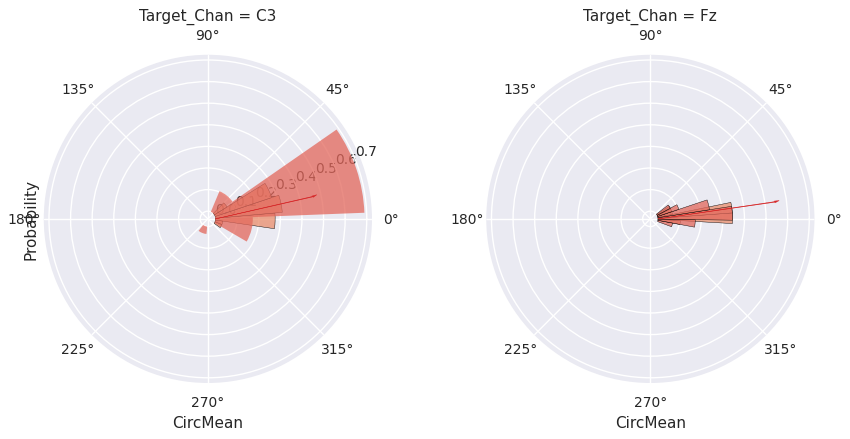

In [5]:
kwargs_arrow={'fc': 'tab:red', 'ec': 'tab:red', 'width': 0.005}
with plt.style.context('seaborn'):
    sns.set_palette("flare")
    g = sns.FacetGrid(df_phase, col='Target_Chan', hue='Stim', #row='Mode',
                      subplot_kws=dict(projection='polar'), height=4.5,  #ylim=(0, 2)
                      sharex=True, sharey=True, despine=False)
    g.map_dataframe(sns.histplot, 'CircMean', stat='probability', bins=6)
    for ax_idx, target_chan in enumerate(df_phase['Target_Chan'].unique()):
        phi = df_phase[df_phase['Target_Chan'] == target_chan]['CircMean'].mean()
        rv = df_phase[df_phase['Target_Chan'] == target_chan]['RVL'].mean()
        print(f'The circular mean for {target_chan} is {phi.round(4)}, and a resultant vector length of : {rv.round(4)}')
        # Rayleigh test for non-uniformity of circular data
        z, pval = pg.circ_rayleigh(df_phase[df_phase['Target_Chan'] == target_chan]['CircMean'])
        print(f'The Rayleigh Z-statistic for non-uniformity of circular data for {target_chan} : {z.round(4)} with a p-value : {pval.round(4)}')
        # V-test for non-uniformity of circular data with a specified mean direction
        V, pvalv = pg.circ_vtest(df_phase[df_phase['Target_Chan'] == target_chan]['CircMean'], dir=0)
        print(f'The V-statistic for non-uniformity of circular data with a specified mean for {target_chan} : {V.round(4)} with a p-value : {pvalv.round(4)}')
        g.axes[0, ax_idx].arrow(0, 0, phi, rv, **kwargs_arrow)
    plt.tight_layout()

In [ ]:
#ax = pg.plot_circmean(df_phase.set_index('Mode').loc['nmes']['CircMean'])

### Evoked Potentials

In [2]:
# Load evoked data (with and without contrasts)
df_evoked = pd.read_pickle(os.path.join(stats_path, 'df_evokeds.p'))
df_evoked.set_index(['Mode','Subject','Night'], inplace=True)
df_evoked = df_evoked.drop(bads, level='Subject')

In [3]:
# Extract grand averages for pinknoise stimulation
gav_pn_sham_c3 = mne.grand_average(list(df_evoked.loc['pn'].Evoked_sham_c3)).crop(tmin=-2, tmax=2)
gav_pn_stim_c3  = mne.grand_average(list(df_evoked.loc['pn'].Evoked_stim_c3)).crop(tmin=-2, tmax=2)
gav_pn_sham_fz = mne.grand_average(list(df_evoked.loc['pn'].Evoked_sham_fz)).crop(tmin=-2, tmax=2)
gav_pn_stim_fz  = mne.grand_average(list(df_evoked.loc['pn'].Evoked_stim_fz)).crop(tmin=-2, tmax=2)

In [4]:
# Extract grand averages for nmes stimulation
gav_nmes_sham_c3 = mne.grand_average(list(df_evoked.loc['nmes'].Evoked_sham_c3)).crop(tmin=-2, tmax=2)
gav_nmes_stim_c3  = mne.grand_average(list(df_evoked.loc['nmes'].Evoked_stim_c3)).crop(tmin=-2, tmax=2)
gav_nmes_sham_fz = mne.grand_average(list(df_evoked.loc['nmes'].Evoked_sham_fz)).crop(tmin=-2, tmax=2)
gav_nmes_stim_fz  = mne.grand_average(list(df_evoked.loc['nmes'].Evoked_stim_fz)).crop(tmin=-2, tmax=2)

In [5]:
# Plotting pararameters
times = np.asarray([-0.5, 0.0, 0.25, 0.5, 0.75, 1])
ts_args = dict(spatial_colors = True, gfp=True, time_unit='s')
topomap_args = dict(outlines = 'head', time_unit='s', time_format = "%0.2f s")

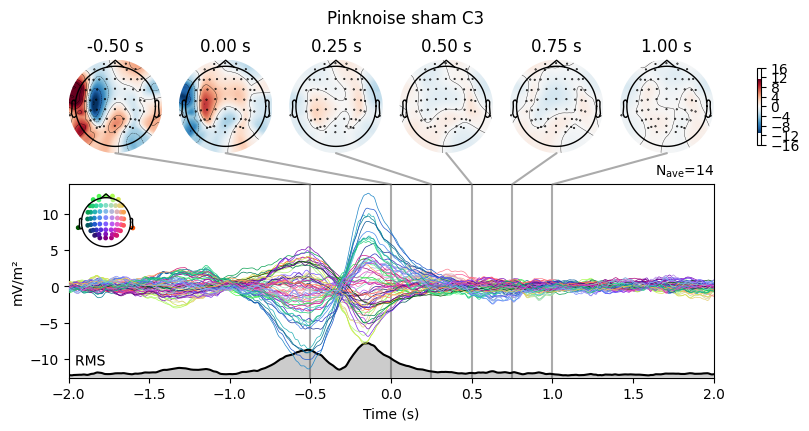

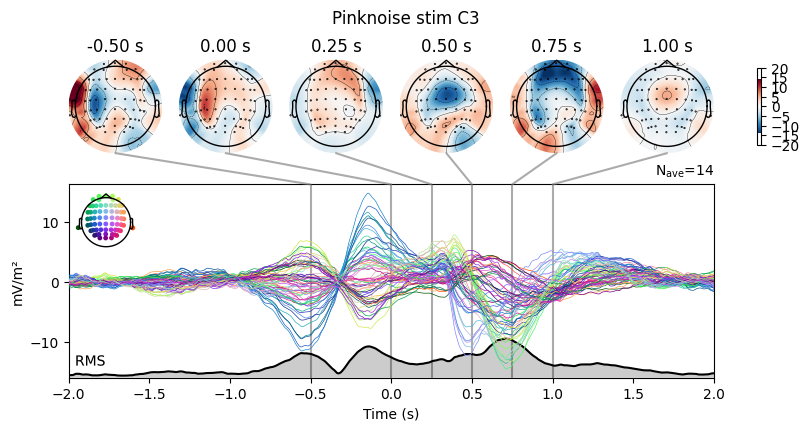

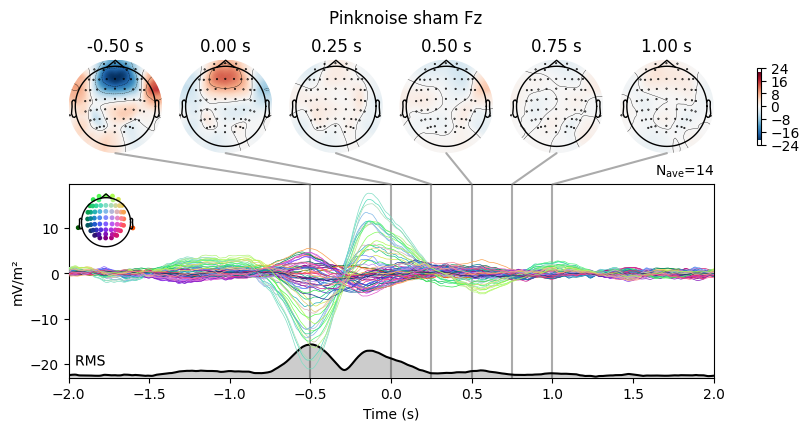

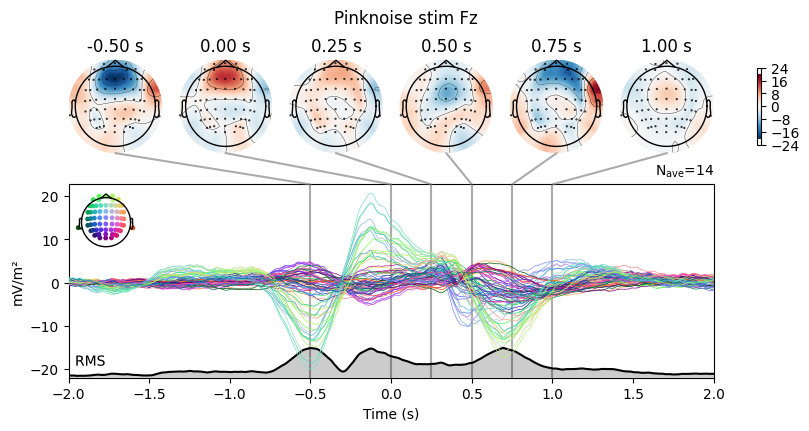

In [6]:
# Plot grand averages for pinknoise stimulation
p1 = gav_pn_sham_c3.plot_joint(title='Pinknoise sham C3', times=times, ts_args=ts_args, topomap_args=topomap_args)
p2 = gav_pn_stim_c3.plot_joint(title='Pinknoise stim C3', times=times, ts_args=ts_args, topomap_args=topomap_args)
p3 = gav_pn_sham_fz.plot_joint(title='Pinknoise sham Fz', times=times, ts_args=ts_args, topomap_args=topomap_args)
p4 = gav_pn_stim_fz.plot_joint(title='Pinknoise stim Fz', times=times, ts_args=ts_args, topomap_args=topomap_args)

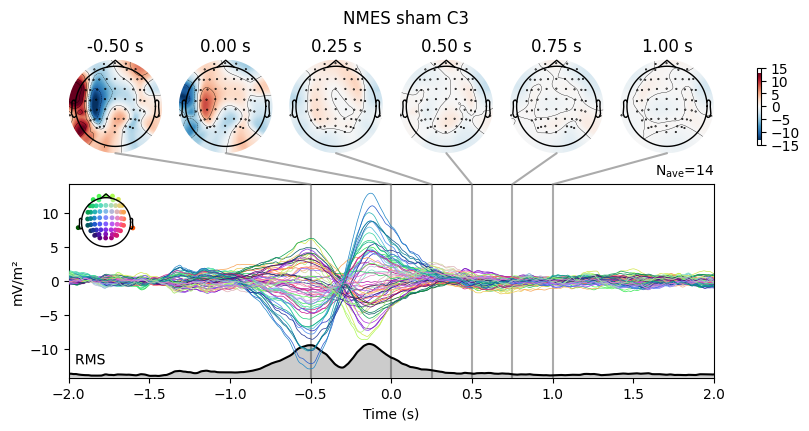

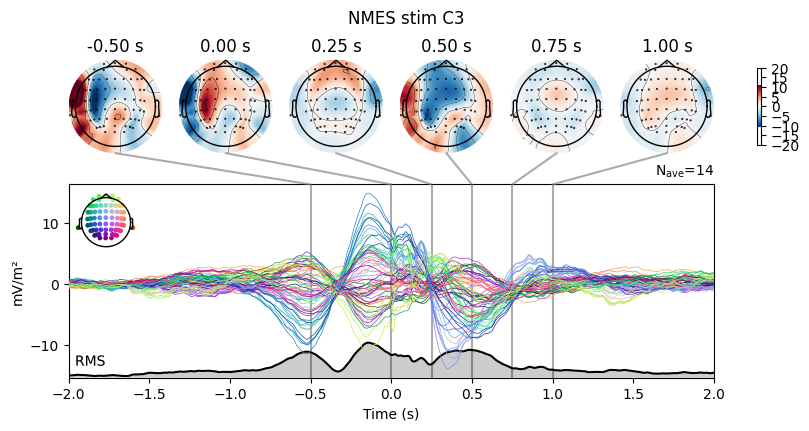

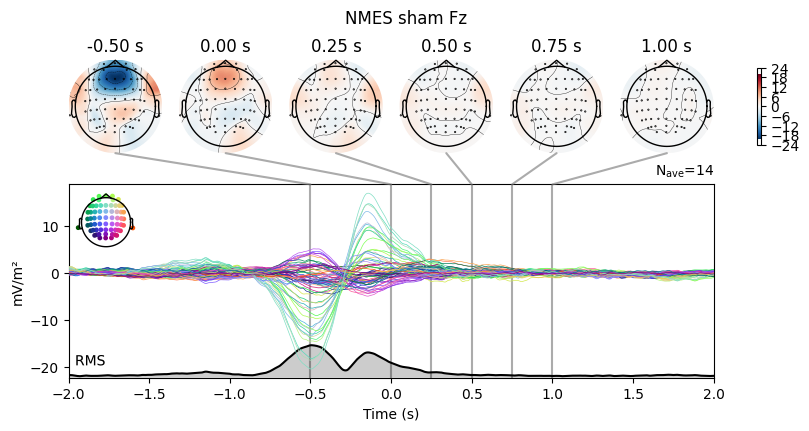

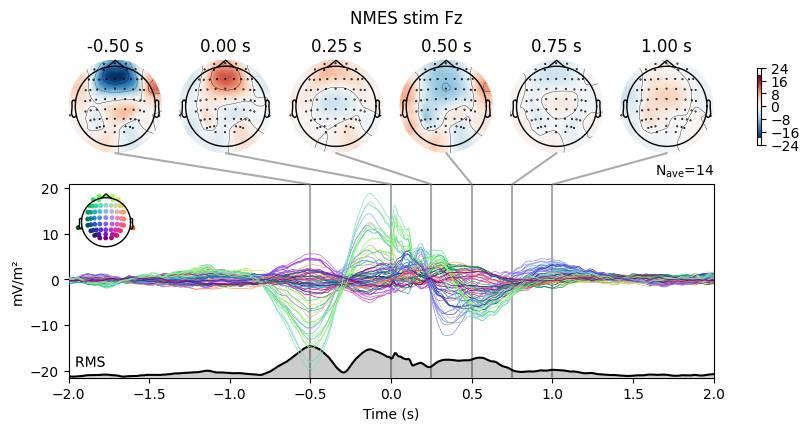

In [7]:
# Plot grand averages for nmes stimulation
p5 = gav_nmes_sham_c3.plot_joint(title='NMES sham C3', times=times, ts_args=ts_args, topomap_args=topomap_args)
p6 = gav_nmes_stim_c3.plot_joint(title='NMES stim C3', times=times, ts_args=ts_args, topomap_args=topomap_args)
p7 = gav_nmes_sham_fz.plot_joint(title='NMES sham Fz', times=times, ts_args=ts_args, topomap_args=topomap_args)
p8 = gav_nmes_stim_fz.plot_joint(title='NMES stim Fz', times=times, ts_args=ts_args, topomap_args=topomap_args)

### SO-Spindle Coupling - ndPAC

In [8]:
# Load the data
df_ndpac = pd.read_csv(os.path.join(stats_path, 'df_ndpac.csv'), index_col=0)
df_ndpac = df_ndpac[~df_ndpac.Subject.isin(bads)]
df_ndpac = df_ndpac[df_ndpac['Session'] == 'Post']
#df_ndpac = df_ndpac[df_ndpac['Mode'] == 'nmes']
df_ndpac

,Subject,Night,Session,Mode,Chan,SigmaPeakTime,PhaseAtSigmaPeak,ndPAC,Stim,Target_Chan
1,LiFe,1,Post,pn,Fp1,0.461384,2.519093,0.296125,sham,c3
3,LiFe,1,Post,pn,Fpz,0.460491,-1.884989,0.302915,sham,c3
5,LiFe,1,Post,pn,Fp2,0.540625,-1.201013,0.302256,sham,c3
7,LiFe,1,Post,pn,F7,0.503571,1.191877,0.370267,sham,c3
9,LiFe,1,Post,pn,F3,0.502455,-1.497052,0.262101,sham,c3
...,...,...,...,...,...,...,...,...,...,...
17911,AnSt,1,Post,nmes,FT8,0.494591,2.398075,0.210667,stim,fz
17913,AnSt,1,Post,nmes,TP7,0.674579,2.865648,0.195633,stim,fz
17915,AnSt,1,Post,nmes,TP8,0.567007,1.379729,0.222748,stim,fz
17917,AnSt,1,Post,nmes,PO7,0.634014,2.694997,0.279990,stim,fz


In [9]:
# Extract the ndPAC condition means
nmes_stim_c3_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['nmes'].loc['stim'].loc['c3']
nmes_sham_c3_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['nmes'].loc['sham'].loc['c3']
nmes_stim_fz_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['nmes'].loc['stim'].loc['fz']
nmes_sham_fz_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['nmes'].loc['sham'].loc['fz']

pn_stim_c3_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['pn'].loc['stim'].loc['c3']
pn_sham_c3_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['pn'].loc['sham'].loc['c3']
pn_stim_fz_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['pn'].loc['stim'].loc['fz']
pn_sham_fz_ndpac = df_ndpac.groupby(['Mode','Stim','Target_Chan','Subject','Chan'])['ndPAC'].mean().loc['pn'].loc['sham'].loc['fz']

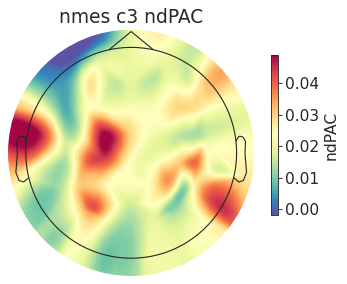

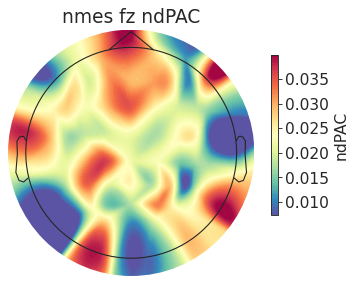

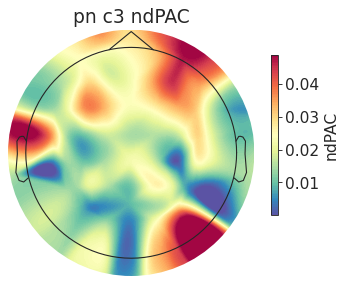

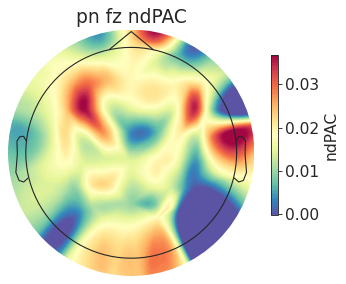

In [10]:
# Plot ndPAC topoplots (stim - sham)
for stim in ['nmes', 'pn']:
    for target in ['c3', 'fz']:
        plot = yasa.topoplot(eval(f'{stim}_stim_{target}_ndpac').groupby('Chan').mean() -
                             eval(f'{stim}_sham_{target}_ndpac').groupby('Chan').mean(), 
                             cmap='Spectral_r', 
                             #vmin=-0.05, vmax=0.05, 
                             contours=False, 
                             title=f'{stim} {target} ndPAC',
                             **dict(names=None)) # type: ignore

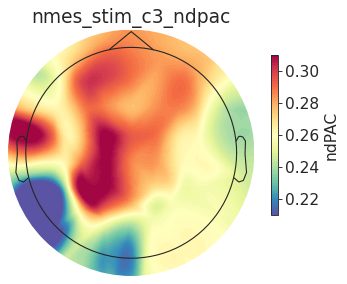

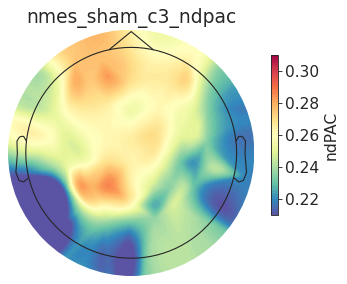

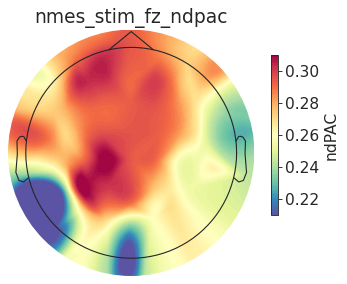

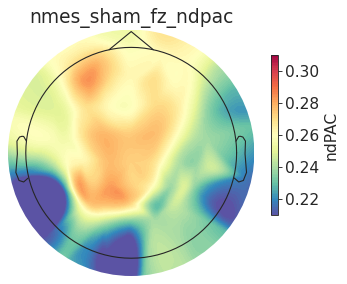

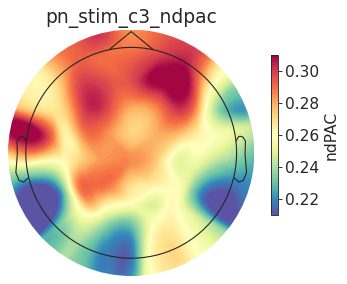

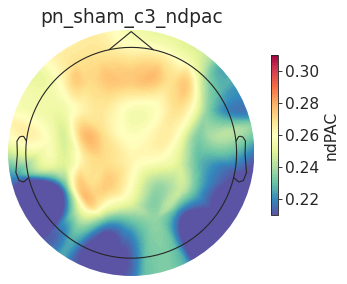

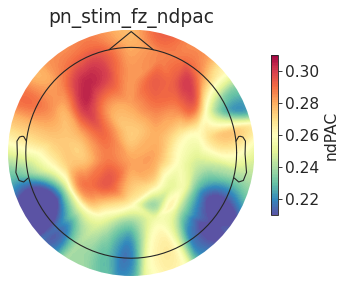

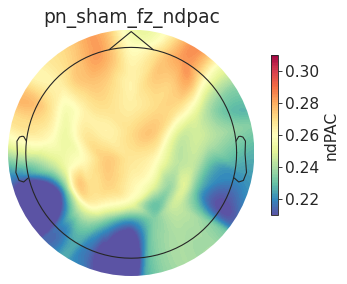

In [11]:
# Plot ndPAC topoplots
for cond in ['nmes_stim_c3_ndpac', 'nmes_sham_c3_ndpac', 'nmes_stim_fz_ndpac', 'nmes_sham_fz_ndpac', 
             'pn_stim_c3_ndpac', 'pn_sham_c3_ndpac', 'pn_stim_fz_ndpac', 'pn_sham_fz_ndpac']:
    plot = yasa.topoplot(eval(cond).groupby('Chan').mean(), 
                         cmap='Spectral_r', 
                         vmin=0.21, vmax=0.31, 
                         contours=False, 
                         title=f'{cond}',
                         **dict(names=None)) # type: ignore

In [12]:
# Get contrast
contrast = prepare_df_to_cond_numpy(df_ndpac[df_ndpac.Mode=='nmes'], features=['ndPAC']).squeeze()
# combine last 2 dimensions of contrast to go from (14, 64, 2, 2) to (14, 64, 4)
new_shape = contrast.shape[:-2] + (-1,)  # This combines the last two dimensions
contrast = contrast.reshape(new_shape)
contrast.shape
np.swapaxes(contrast, 2, 1).shape

NameError: name 'prepare_df_to_cond_numpy' is not defined

In [11]:
# Convert dfs to numpy arrays (subject x channel x feature)
contrast = prepare_df_to_cond_numpy(df_ndpac[df_ndpac.Mode=='nmes'], features=['ndPAC']).squeeze()
nmes_c3_ndpac = contrast[:, :, 1, 0] - contrast[:, :, 0, 0]
nmes_fz_ndpac = contrast[:, :, 1, 1] - contrast[:, :, 0, 1]

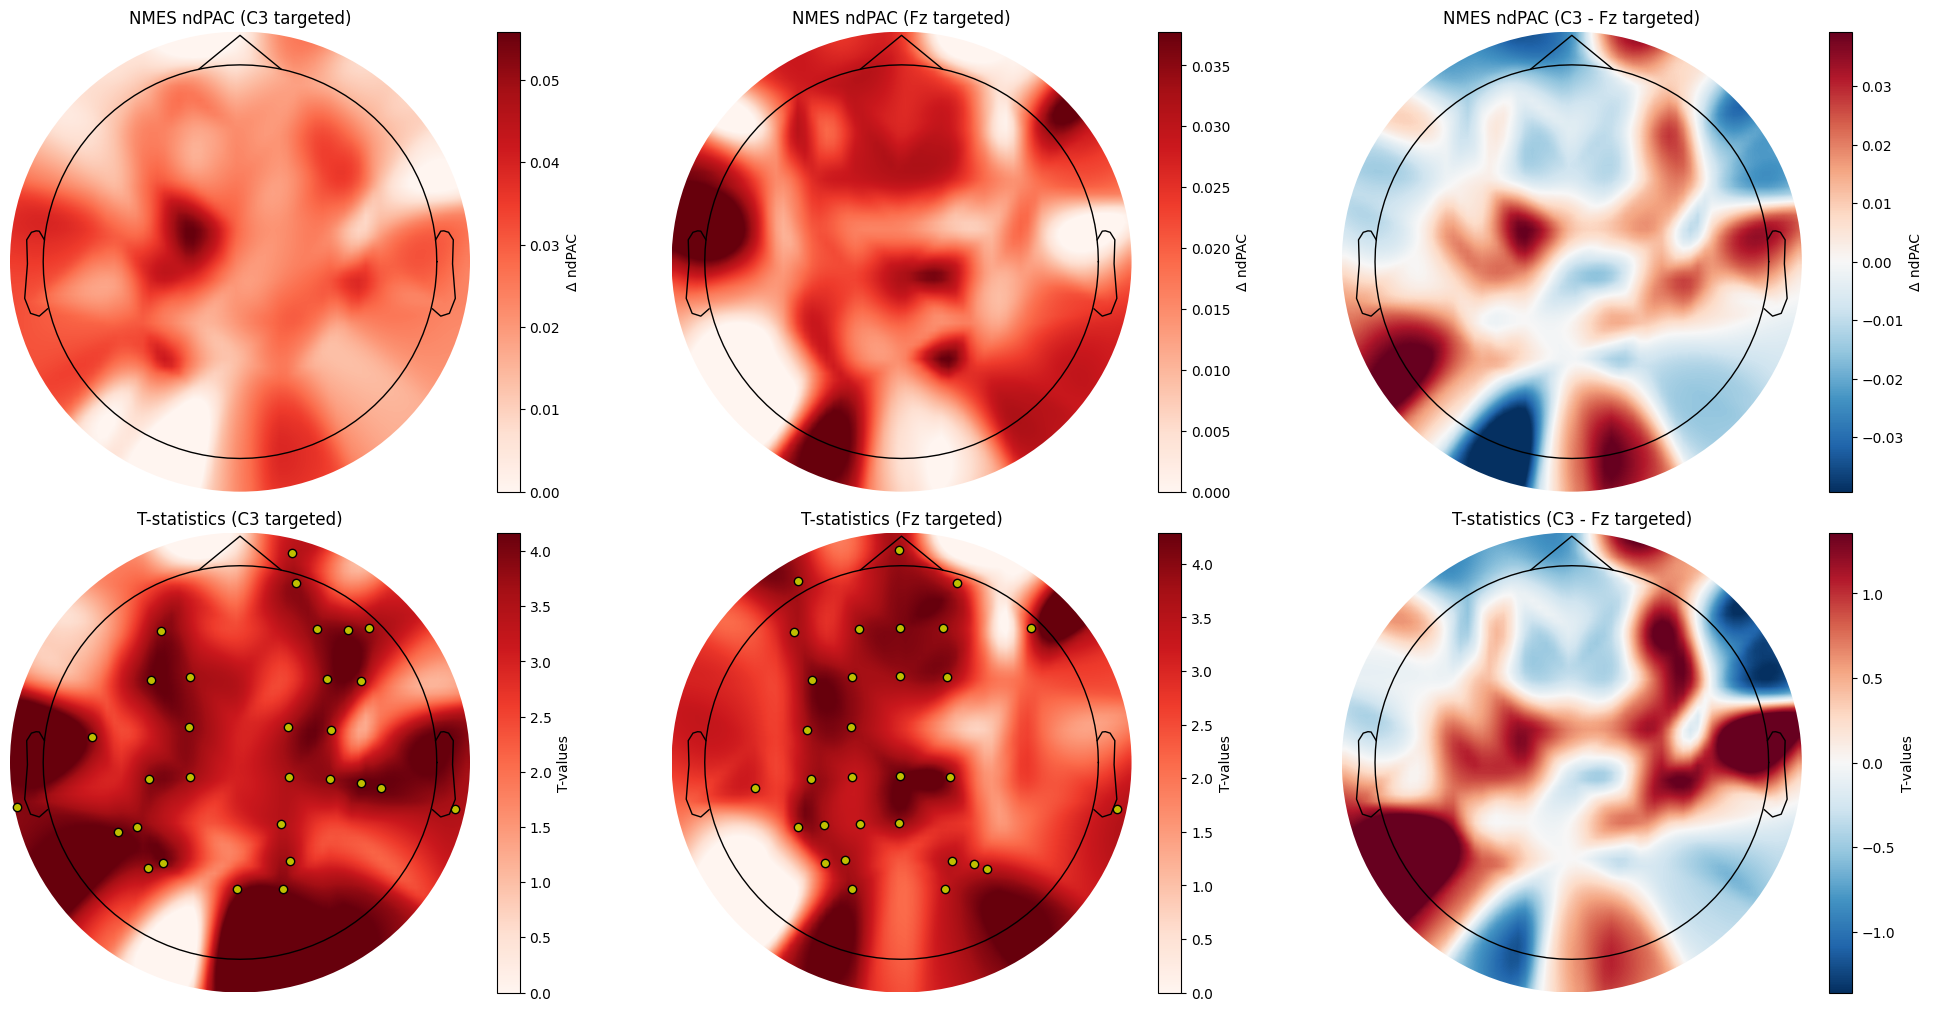

In [20]:
# Load epochs outside the loop to improve efficiency
adj_epochs = mne.read_epochs('/media/administrator/Sleep_Data/Processed/Sleep/Intermediate/LuPf_1_1-epo.fif')
adjacency, ch_names = mne.channels.find_ch_adjacency(adj_epochs.info, 'eeg')

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(20, 10), layout="constrained")
ndpac_contrasts = [nmes_c3_ndpac, nmes_fz_ndpac, nmes_c3_ndpac - nmes_fz_ndpac]
names = ["C3", "Fz", "C3 - Fz"]

# Plot ndPAC on the top row
for ax, contrast, name in zip(axes[0], ndpac_contrasts, names):
    # Plot ndPAC
    mne.viz.plot_topomap(contrast.mean(0), 
                         pos=gav_nmes_sham_c3.info, 
                         contours=False, 
                         show=False, 
                         sensors=False, 
                         #cmap='Spectral_r',
                         axes=ax)
    ax.set_title(f'NMES ndPAC ({name} targeted)')
    cbar = plt.colorbar(ax.images[-1], ax=ax, orientation="vertical")
    cbar.set_label('\u0394 ' + 'ndPAC')

# Plot T-stats on the bottom row
for ax, contrast, name in zip(axes[1], ndpac_contrasts, names):
    # Perform statistical test
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        contrast,
        n_permutations=1024,
        threshold=dict(start=0, step=0.2),
        tail=0,
        adjacency=adjacency,
        out_type="mask",
        n_jobs=-1)
    
    # Plot T-statistics with significance masking
    mne.viz.plot_topomap(T_obs, 
                         pos=gav_nmes_sham_c3.info, 
                         contours=False,
                         mask=cluster_p_values < 0.05,
                         mask_params=dict(markersize=6, markerfacecolor='y'), 
                         show=False, 
                         sensors=False, 
                         #cmap='Spectral_r',
                         axes=ax)
    ax.set_title(f'T-statistics ({name} targeted)')
    cbar = plt.colorbar(ax.images[-1], ax=ax, orientation="vertical")
    cbar.set_label("T-values")

In [ ]:
# Stats
def group_sleep_ndpac_stats(contrast, title=None):
    # prepare adjacency matrix, must load (any) non-csd mne epochs info
    adj_epochs = mne.read_epochs('/media/administrator/Sleep_Data/Processed/Sleep/Intermediate/LuPf_1_1-epo.fif')
    adjacency, ch_names = mne.channels.find_ch_adjacency(adj_epochs.info, 'eeg')

    # set parameters
    n_observations = contrast.shape[0]
    factor_levels = [2, 2] 
    effects = "A:B"

    # The ANOVA returns a tuple f-values and p-values, we will pick the former.
    pthresh = 0.05  
    f_thresh = mne.stats.f_threshold_mway_rm(n_observations, factor_levels, effects, pthresh)
    tail = 1  # f-test, so tail > 0

    def stat_fun(*args):
        return mne.stats.f_mway_rm(
            np.swapaxes(args, 2, 1), #np.swapaxes(args, 1, 0),
            factor_levels=factor_levels,
            effects=effects,
            return_pvals=False,
        )[0]

    # The ANOVA returns a tuple f-values and p-values, we will pick the former.
    pthresh = 0.05  
    f_thresh = mne.stats.f_threshold_mway_rm(n_observations, factor_levels, effects, pthresh)
    F_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            contrast,
            adjacency=adjacency,
            stat_fun=stat_fun,
            threshold=f_thresh,
            tail=tail,
            n_jobs=-1,
            n_permutations=1024,
            buffer_size=None,   
            out_type="mask",
        )
    
    return F_obs, clusters, cluster_p_values, H0

#F_obs, clusters, cluster_p_values, H0 = group_sleep_ndpac_stats(contrast)

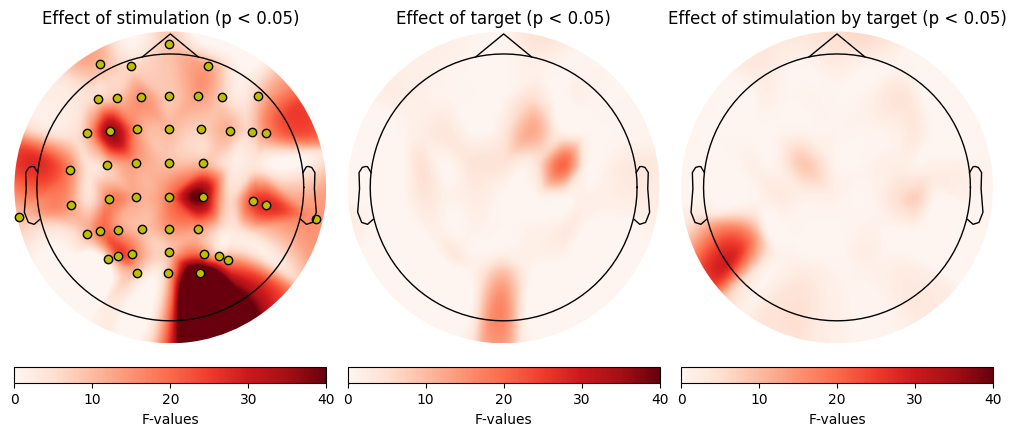

In [22]:
contrast = prepare_df_to_cond_numpy(df_ndpac[df_ndpac.Mode=='nmes'], features=['ndPAC']).squeeze()
new_shape = contrast.shape[:-2] + (-1,)  # This combines the last two dimensions
contrast = contrast.reshape(new_shape)

fvals, pvals = mne.stats.f_mway_rm(contrast.swapaxes(2, 1), factor_levels=[2, 2], effects="A*B")

effect_labels = ["stimulation", "target", "stimulation by target"]

#masks, _ = mne.stats.fdr_correction(pvals)

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, layout="constrained")
# let's visualize our effects by computing f-images
for effect, pval, effect_label, ax in zip(fvals, pvals, effect_labels, axes):
    masks, _ = mne.stats.fdr_correction(pval)
    mne.viz.plot_topomap(effect, 
                         pos=gav_pn_sham_c3.info, 
                         vlim=(0, 40),
                         contours=False,
                         mask=masks, #pval < 0.05,
                         mask_params=dict(markersize=6, markerfacecolor='y'), 
                         axes=ax,
                         sensors=False,
                         show=False, 
                         )
    ax.set_title(f"Effect of {effect_label} (p < 0.05)")
    # add a colorbar
    cbar = plt.colorbar(ax.images[-1], ax=ax, orientation="horizontal")
    cbar.set_label("F-values")

In [ ]:
def group_sleep_ndpac_stats(contrast):
    # Load adjacency information
    adj_epochs = mne.read_epochs('/media/administrator/Sleep_Data/Processed/Sleep/Intermediate/LuPf_1_1-epo.fif')
    adjacency, ch_names = mne.channels.find_ch_adjacency(adj_epochs.info, 'eeg')

    # Define your statistical function
    # set parameters
    n_observations = contrast.shape[0]
    factor_levels = [2, 2] 
    effects = 'all' #"A*B"

    def stat_fun(*args):
        return mne.stats.f_mway_rm(
            np.swapaxes(args, 2, 1), #np.swapaxes(args, 1, 0),
            factor_levels=factor_levels,
            effects=effects,
            return_pvals=False,
        )[0]
    
    # Prepare data for permutation cluster test
    # Assuming 'contrast' is structured appropriately for your 2x2 design
    # Each 'slice' of your data now needs to be prepared according to the specific analysis
    # Since MNE's permutation test doesn't directly support 2x2 RM ANOVA, you'd typically
    # perform separate permutation tests for each condition or compute stats differently

    # Placeholder for loop over conditions if needed
    # Adjust according to how you compute the stat_fun over your factorial design
    res = []
    for cond in range(contrast.shape[-1]):
        F_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            contrast[:,:, [cond]],  # Adjust based on your data structure
            adjacency=adjacency,
            stat_fun=stat_fun,
            n_permutations=1024,
            tail=1,  
            threshold=None,  # No thresholding, use cluster-level statistics
            n_jobs=-1,
        )
        
        res.append((F_obs, clusters, cluster_p_values, H0))

    return F_obs, clusters, cluster_p_values, H0

In [ ]:
group_sleep_ndpac_stats(contrast)

### SO-Spindle Coupling - ERPAC

In [ ]:
# Load ERPAC data
df_erpac = pd.read_pickle(os.path.join(stats_path, 'df_erpac.p'))
df_erpac = df_erpac[~df_erpac.Subject.isin(bads)]
df_erpac

In [ ]:
practice_st = df_erpac.set_index(['Mode','Stim','Target_Chan','Subject','Night']).loc['pn'].loc['stim'].loc['c3'].ERPAC.to_numpy()
practice_sh = df_erpac.set_index(['Mode','Stim','Target_Chan','Subject','Night']).loc['pn'].loc['sham'].loc['c3'].ERPAC.to_numpy()

erpacs_st = np.concatenate([np.expand_dims(practice_st[i], axis=0) for i in range(len(practice_st))], 0)
erpacs_sh = np.concatenate([np.expand_dims(practice_sh[i], axis=0) for i in range(len(practice_sh))], 0)

erpacs = erpacs_st - erpacs_sh

times = np.arange(-2, 2, 1/128)
freqs = np.arange(5, 25, .25)

plt.figure(figsize=(15, 8))
plt.imshow(erpacs, aspect='auto', origin='lower', cmap='viridis', 
           extent=[times.min(), times.max(), freqs.min(), freqs.max()])
plt.colorbar(label='ERPAC Coupling Strength')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('ERPAC Results')
plt.axvline(0., linestyle='--', color='w', linewidth=2)
plt.show()

In [ ]:
erpacs_st.shape

In [ ]:
pac_r1 = erpacs_st
pac_r2 = erpacs_sh

n_perm = 1000  # number of permutations
tail = 1       # only inspect the upper tail of the distribution
# perform the correction
t_obs, clusters, cluster_p_values, h0 = mne.stats.permutation_cluster_test(
    [pac_r1[:,:,256:], pac_r2[:,:,256:]], n_permutations=n_perm, tail=tail)

In [ ]:
plt.figure(figsize=(15, 8))
plt.imshow(t_obs, aspect='auto', origin='lower', cmap='viridis', 
           extent=[times.min(), times.max(), freqs.min(), freqs.max()])
plt.colorbar(label='ERPAC Coupling Strength')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('ERPAC Results')
plt.axvline(0., linestyle='--', color='w', linewidth=2)
plt.show()

## Sleep Macroarchitecture Analysis 

### Sleep Statistics 

In [ ]:
# Load the sleep macroarchitecture
sleep_stats_df = pd.read_csv(os.path.join(stats_path, 'df_sleep_stats.csv'), index_col=0)
sleep_stats_df.set_index(['Mode','Subject','Night'], inplace=True)
sleep_stats_df = sleep_stats_df.drop(bads, level='Subject')

In [ ]:
# Perform stats
sleep_stats_df

In [ ]:
# Perform ttests comparing modes with pingouin , check for normality first
for param in sleep_stats_df.columns[3:]:
    # print(pg.normality(sleep_stats_df[param]))
    # if normal, perform paired ttest otherwise, use mannwhitney
    print(f'Performing ttest for {param}')
    if pg.normality(sleep_stats_df[param]).pval[0] > 0.05:
        print(pg.ttest(sleep_stats_df[sleep_stats_df['Mode']=='nmes'][param], 
                       sleep_stats_df[sleep_stats_df['Mode']=='pn'][param], paired=False))
    else:
        print(f'Performing Mann-Whitney U test for {param}')
        print(pg.mwu(sleep_stats_df[sleep_stats_df.Mode=='nmes'][param],
                     sleep_stats_df[sleep_stats_df.Mode=='pn'][param], 
                     alternative='two-sided'))

### Transition Probabilities

In [ ]:
# Load the summary
trans_df = pd.read_csv(os.path.join(stats_path, 'df_trans.csv'), index_col='From Stage')
trans_df.drop(columns=['Unnamed: 0'], inplace=True)
numeric_columns = [str(i) for i in range(5)] 
new_columns = pd.MultiIndex.from_tuples([('To Stage', col) if col in numeric_columns else ('', col) for col in trans_df.columns])
trans_df.columns = new_columns
trans_df

In [ ]:
# Plot transition matrix with sns heatmap
grid_kws = {"height_ratios": (.9, .05), "hspace": .1}
f, (ax, cbar_ax) = plt.subplots(2, gridspec_kw=grid_kws,
                                figsize=(5, 5))
sns.heatmap(trans_df, ax=ax, square=False, vmin=0, vmax=1, cbar=True,
            cbar_ax=cbar_ax, cmap='YlOrRd', annot=True, fmt='.2f',
            cbar_kws={"orientation": "horizontal", "fraction": 0.1,
                      "label": "Transition probability"})

ax.set_xlabel("To sleep stage")
ax.xaxis.tick_top()
ax.set_ylabel("From sleep stage")
ax.xaxis.set_label_position('top')

## Sleep Microarchitecture Analysis

### Power Spectral Analysis

In [ ]:
# Load the summary
power_df = pd.read_csv(os.path.join(stats_path, 'df_power.csv'), index_col=0)
power_df = power_df[~power_df.Subject.isin(bads)]
power_df

In [ ]:
contrasts = prepare_df_to_numpy(power_df[power_df.Mode=='nmes'], 
                                features=['Delta', 'Theta', 'Alpha', 'Sigma', 'Beta','Aperiodic'])

In [ ]:
yasa.topoplot(pd.Series(T0, index=power_df_scaled.Chan.unique()), 
              cmap='RdBu_r', title='t-values')

In [ ]:
delta_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,0], title='Delta Stats')
theta_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,1], title='Theta Stats')
alpha_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,2], title='Alpha Stats')
sigma_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,3], title='Sigma Stats')
beta_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,4], title='Beta Stats')
aperiodic_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,5], title='Aperiodic Stats')

In [ ]:
# Plot the relative power by sleep stage 
ax, fig = plt.subplots(2, 3, figsize=(15, 10))
fig = fig.flatten()
for i, band in enumerate(['Delta', 'Theta', 'Alpha', 'Sigma', 'Beta', 'Aperiodic']):
    sns.barplot(power_df, x='Mode', y=band, ax=fig[i]) 
    fig[i].set_title(band)
    fig[i].set_xlabel('Sleep stage')
    fig[i].set_ylabel('Relative power')
    #fig[i].set_ylim(0, np.percentile([power_df], 99)*1.1)
plt.tight_layout()

### SO/Spindle Coupling

In [ ]:
# Load the summary
ndpac_df = pd.read_csv(os.path.join(stats_path, 'df_ndpac.csv'), index_col=0)
ndpac_df = ndpac_df.drop(bads, level='Subject')
ndpac_df

In [ ]:
contrasts = prepare_df_to_numpy(ndpac_df[ndpac_df.Session=='Post'], 
                                features=['SigmaPeakTime','PhaseAtSigmaPeak','ndPAC'])

In [ ]:
ndpac_stats = group_sleep_stats(gav_nmes_sham_c3, contrasts[:,:,0], title='ndPAC Stats')

### Slow Waves and Spindle Statistics

In [ ]:
# Load summary of spindles
spindles_df = pd.read_csv(os.path.join(stats_path, 'df_spindles.csv'), index_col=0)
spindles_df = spindles_df[~spindles_df.Subject.isin(bads)]
spindles_df

In [ ]:
# Load summary of slow waves
sw_df = pd.read_csv(os.path.join(stats_path, 'df_sw.csv'), index_col=0)
sw_df = sw_df[~sw_df.Subject.isin(bads)]
sw_df

In [ ]:
# apply sin and cos transformation to circular data (PhaseAtSigmaPeak)
sw_df['PhaseAtSigmaPeak_sin'] = np.sin(sw_df['PhaseAtSigmaPeak'])
sw_df['PhaseAtSigmaPeak_cos'] = np.cos(sw_df['PhaseAtSigmaPeak'])

In [ ]:
import statsmodels.api as sm

# Fit your models
model1 = sm.MixedLM.from_formula('ndPAC ~ PhaseAtSigmaPeak_sin + PhaseAtSigmaPeak_cos', groups='Subject', data=sw_df.dropna()).fit()
model0 = sm.MixedLM.from_formula('ndPAC ~ 1', groups='Subject', data=sw_df.dropna()).fit()

from scipy.stats import chi2

# Calculate the likelihood ratio statistic
lr_statistic = 2 * (model1.llf - model0.llf)

# Calculate degrees of freedom difference
df_diff = model1.df_modelwc - model0.df_modelwc

# Calculate the p-value
p_value = chi2.sf(lr_statistic, df_diff)

print(f"Likelihood ratio statistic: {lr_statistic}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom difference: {df_diff}")

## Resting State Analysis

### Spectral changes overnight

In [126]:
# Load resting state data
rs_df = pd.read_csv(os.path.join(stats_path, 'df_rs.csv'), index_col=0)
#rs_df = rs_df[~rs_df.Subject.isin(bads)]
rs_df

,Subject,Night,Condition,Session,Mode,Chan,Delta,Theta,Alpha,Beta,TotalAbsPow,FreqRes,Relative,Offset,Aperiodic
0,LaSt,2,eyes_open,pre,pn,Fp1,0.203305,0.169243,0.064580,0.562873,0.000011,0.5,True,-6.018456,0.607373
1,LaSt,2,eyes_open,pre,pn,Fpz,0.231668,0.203012,0.071231,0.494090,0.000021,0.5,True,-5.653819,0.696322
2,LaSt,2,eyes_open,pre,pn,Fp2,0.191534,0.184576,0.072499,0.551392,0.000015,0.5,True,-5.986059,0.451866
3,LaSt,2,eyes_open,pre,pn,F7,0.201277,0.093498,0.056291,0.648934,0.000016,0.5,True,-5.989546,0.470959
4,LaSt,2,eyes_open,pre,pn,F3,0.116918,0.102659,0.052808,0.727615,0.000020,0.5,True,-6.162526,0.277331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,LuPf,1,eyes_closed,post,nmes,FT8,0.245949,0.172159,0.429602,0.152289,0.000020,0.5,True,-5.372213,1.123149
5372,LuPf,1,eyes_closed,post,nmes,TP7,0.214438,0.112099,0.527377,0.146086,0.000008,0.5,True,-5.839256,1.123973
5373,LuPf,1,eyes_closed,post,nmes,TP8,0.072275,0.033626,0.833652,0.060446,0.000138,0.5,True,-5.106956,1.181486
5374,LuPf,1,eyes_closed,post,nmes,PO7,0.087511,0.032278,0.832926,0.047285,0.000116,0.5,True,-4.999871,1.440910


In [140]:
# Create contrast array
post = prepare_df_to_numpy(rs_df[np.logical_and(rs_df.Mode=='nmes',rs_df.Session=='post')], 
                                 features=['Delta', 'Theta', 'Alpha', 'Beta', 'Aperiodic'])
pre = prepare_df_to_numpy(rs_df[np.logical_and(rs_df.Mode=='nmes',rs_df.Session=='pre')],
                                features=['Delta', 'Theta', 'Alpha', 'Beta', 'Aperiodic'])
contrasts = post[0:8, :, :] - pre[0:8, :, :]
contrasts.shape

(8, 64, 5)

Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_plugin_pandas_types
Unable to load extension: pydevd_plugins.extensions.types.pydevd_

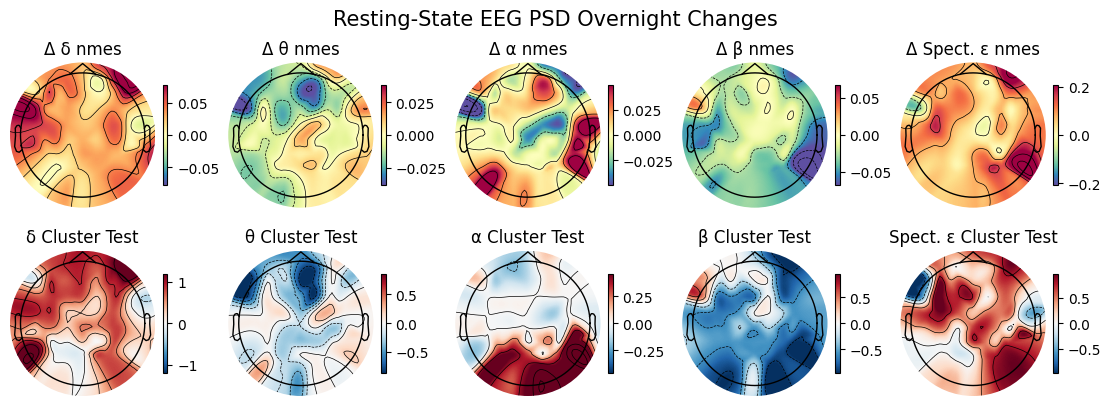

In [149]:
def plot_psd_stats_diff(rs_df, contrasts, adjacency, gav_info):
    # Adjust figsize as needed to accommodate 3 rows of plots
    fig, axes = plt.subplots(2, 5, figsize=(2.2 * 5, 2.7 * 1.5), constrained_layout=True)
    fig.suptitle('Resting-State EEG PSD Overnight Changes', fontsize=15)

    grk = ['\u03B4', '\u03B8', '\u03B1', '\u03B2', 'Spect. ' '\u03B5']  # Greek letters for EEG bands
    
    # Assuming 'Mode' differentiates conditions and 'Band' for EEG bands
    modes = np.unique(rs_df['Mode'])
    bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Aperiodic']

    # Ensure contrasts array is correctly ordered and aligned with 'bands'
    for ind, band in enumerate(bands):
        # Get the PSD diff across channels for the current band
        bp_contrast_post = rs_df.groupby(['Session','Chan'])[f'{band}'].mean().loc['post'] 
        bp_contrast_post = bp_contrast_post.reindex(list(rs_df.Chan.unique()))
        bp_contrast_pre = rs_df.groupby(['Session','Chan'])[f'{band}'].mean().loc['pre']
        bp_contrast_pre = bp_contrast_pre.reindex(list(rs_df.Chan.unique()))
        bp_contrast = bp_contrast_post - bp_contrast_pre

        # Plot
        im, cn = mne.viz.plot_topomap(bp_contrast, 
                                    pos=gav_nmes_sham_c3.info, 
                                    cmap='Spectral_r', 
                                    #vlim=(-0.1, 0.1),
                                    #contours=0,
                                    sensors=False, 
                                    axes=axes[0, ind], 
                                    show=False, names=None)
        
        # add color bar
        mne.viz.topomap._add_colorbar(axes[0,ind], im, cmap = 'Spectral_r', 
                                    #side='right', pad=0.05, size='5%'
                                    title=None, format=None)
            
        # Set the plot title
        axes[0, ind].set_title('\u0394 ' + grk[ind] + f' {modes[0]}')

        # Permutation test plotting in the third row for each band
        T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            contrasts[:, :, ind].squeeze(),  # Adjust this to access the correct contrast data for the current band
            n_permutations=1024,
            threshold=dict(start=0, step=0.2),
            tail=0,
            adjacency=adjacency,
            out_type='mask',
            n_jobs=-1)

        # Plotting permutation test results
        im2, cn2 = mne.viz.plot_topomap(T_obs, pos=gav_info, 
                            mask=cluster_p_values < 0.05, mask_params=dict(markersize=5, markerfacecolor='yellow'), 
                            axes=axes[1, ind], show=False, #contours=0,
                            sensors=False, cmap='RdBu_r')
        mne.viz.topomap._add_colorbar(axes[1, ind], im2, cmap = 'RdBu_r', 
                                      title=None, format=None)
        axes[1, ind].set_title(f'{grk[ind]} Cluster Test')

    # Adjust layout
    #plt.tight_layout()

plot_psd_stats_diff(rs_df[np.logical_and(rs_df.Condition=='eyes_closed', rs_df.Mode=='nmes')], 
                    contrasts, adjacency, gav_nmes_sham_c3.info)

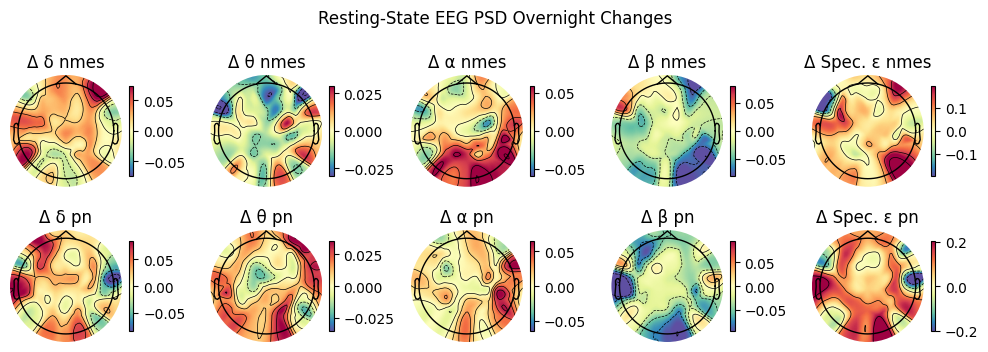

In [150]:
# Plot result
def plot_psd_diff(rs_df):
    fig, axes = plt.subplots(2, 5, figsize=(2 * 5, 2.5 * 1.5))
    fig.suptitle('Resting-State EEG PSD Overnight Changes')
    grk = ['\u03B4', '\u03B8', '\u03B1', '\u03B2', 'Spec. ' '\u03B5']
    for idx, cond in enumerate(np.unique(rs_df.Mode)):
        for ind, band in enumerate(['Delta', 'Theta', 'Alpha', 'Beta', 'Aperiodic']):
                        
            # Get the PSD diff across channels for the current band
            bp_contrast_post = rs_df.groupby(['Session','Mode','Chan'])[f'{band}'].mean().loc['post'][cond] 
            bp_contrast_post = bp_contrast_post.reindex(list(rs_df.Chan.unique()))
            bp_contrast_pre = rs_df.groupby(['Session','Mode','Chan'])[f'{band}'].mean().loc['pre'][cond]
            bp_contrast_pre = bp_contrast_pre.reindex(list(rs_df.Chan.unique()))
            bp_contrast = bp_contrast_post - bp_contrast_pre

            # Plot
            im, cn = mne.viz.plot_topomap(bp_contrast, 
                                          pos=gav_nmes_sham_c3.info, 
                                          cmap='Spectral_r', 
                                          #vlim=(-0.1, 0.1),
                                          #contours=0,
                                          sensors=False, 
                                          axes=axes[idx, ind], 
                                          show=False, names=None)
            
            # add color bar
            mne.viz.topomap._add_colorbar(axes[idx,ind], im, cmap = 'Spectral_r', 
                                          #side='right', pad=0.05, size='5%'
                                          title=None, format=None)
                
            # Set the plot title
            axes[idx, ind].set_title('\u0394 ' + grk[ind] + f' {cond}')
            
        # tighten layout
        plt.tight_layout()
    
    
plot_psd_diff(rs_df[rs_df.Condition=='eyes_open'])

In [166]:
# get index of only frontocentral channels
frontocentral = ['Fz', 'FC1', 'FC2', 'Cz', 'C1', 'C2']
fc_df = rs_df[rs_df.Chan.isin(frontocentral)]
# mean over fc channels
fc_df = fc_df.groupby(['Mode', 'Condition','Subject', 'Session']).mean()
# only eyes open condition and nmes modes
fc_df = fc_df.loc['nmes'].loc['eyes_closed']
# drop RoKi
fc_df = fc_df.drop('RoKi')
fc_df.reset_index(inplace=True)
fc_df

/tmp/ipykernel_1165081/3949833990.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  fc_df = fc_df.groupby(['Mode', 'Condition','Subject', 'Session']).mean()


,Subject,Session,Night,Delta,Theta,Alpha,Beta,TotalAbsPow,FreqRes,Relative,Offset,Aperiodic
0,FlHa,post,1.0,0.258309,0.133487,0.395594,0.212611,0.000005,0.5,1.0,-6.053061,1.079219
1,FlHa,pre,1.0,0.268004,0.183434,0.308322,0.240240,0.000012,0.5,1.0,-5.695366,0.941896
2,KeWo,post,1.0,0.220192,0.309664,0.290004,0.180140,0.000018,0.5,1.0,-5.486289,1.101799
3,KeWo,pre,1.0,0.279651,0.273867,0.222955,0.223527,0.000015,0.5,1.0,-5.500316,1.101607
4,LaKu,post,1.0,0.147779,0.096395,0.598536,0.157290,0.000017,0.5,1.0,-5.784865,0.927258
5,LaKu,pre,1.0,0.113799,0.098473,0.587433,0.200295,0.000023,0.5,1.0,-5.796821,0.775334
6,LaSt,post,1.0,0.304471,0.182186,0.182272,0.331071,0.000014,0.5,1.0,-5.631873,0.878972
7,LaSt,pre,1.0,0.249121,0.194015,0.225925,0.330940,0.000010,0.5,1.0,-5.734530,0.938471
8,LiJo,post,1.0,0.307257,0.181840,0.147544,0.363359,0.000040,0.5,1.0,-5.282099,0.767648
9,LiJo,pre,1.0,0.259548,0.254153,0.152916,0.333382,0.000021,0.5,1.0,-5.475744,0.841627


<Axes: xlabel='Session', ylabel='Delta'>

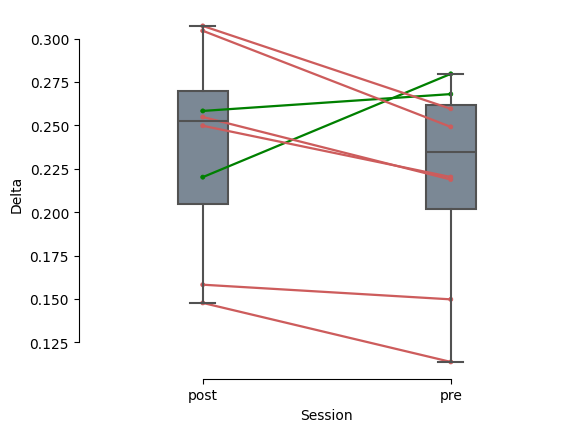

In [188]:
pg.plot_paired(fc_df, dv='Delta', within='Session', subject='Subject')         

In [187]:
# t-test for theta
import statsmodels.formula.api as smf
res = smf.ols(formula="Theta ~ Session + 1", data=fc_df).fit()
pg.ttest(fc_df[fc_df.Session=='post'].Theta, fc_df[fc_df.Session=='pre'].Theta, paired=True)
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  Theta   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.068
Method:                 Least Squares   F-statistic:                   0.04876
Date:                Tue, 05 Mar 2024   Prob (F-statistic):              0.828
Time:                        17:36:02   Log-Likelihood:                 19.962
No. Observations:                  16   AIC:                            -35.92
Df Residuals:                      14   BIC:                            -34.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.1950      0.026      7.

/home/administrator/anaconda3/envs/NDS/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


### Heart Rate Variability changes overnight

In [ ]:
# Load the HRV data
hrv_rs_df = pd.read_csv(os.path.join(stats_path, 'df_rs_hrv.csv'), index_col=0)
hrv_rs_df = hrv_rs_df[~hrv_rs_df.Subject.isin(bads)]
hrv_rs_df